Analyze the predictions of the images (with the models trained including hyssopifolia in the training data) to understand Precision, Recall (=accuracy in this case) and F1 score

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pred_with_hyss_path = "./support_files/full_predictions_with_logits_including_hyssopifolia.csv"
predictions_with_hyssopifolia = pd.read_csv(pred_with_hyss_path)

predictions_with_hyssopifolia

,obs_id,filename,group,y_true,y_pred,logit_c0,prob_c0,logit_c1,prob_c1
0,0,lythrum_salicaria_001.jpg,lythrum_salicaria,0,1,-1.0404499769210815,0.11952177435159683,0.956516683101654,0.8804782032966614
1,1,lythrum_salicaria_002.jpg,lythrum_salicaria,0,0,0.7825840711593628,0.8388816118240356,-0.8673464059829712,0.16111834347248077
2,2,lythrum_salicaria_003.jpg,lythrum_salicaria,0,0,0.6907409429550171,0.8090329766273499,-0.7529979944229126,0.19096702337265015
3,3,lythrum_salicaria_004.jpg,lythrum_salicaria,0,0,0.3273944556713104,0.674139678478241,-0.3995742201805115,0.32586029171943665
4,4,lythrum_salicaria_005.jpg,lythrum_salicaria,0,1,-0.9497829079627991,0.14243805408477783,0.845403254032135,0.8575618863105774
...,...,...,...,...,...,...,...,...,...
45385,obs_id,filename,group,y_true,y_pred,logit_c0,prob_c0,logit_c1,prob_c1
45386,34705,lythrum_silenoides_001.jpeg,lythrum_silenoides,1,1,-2.9456686973571777,0.003085881471633911,2.8321585655212402,0.9969141483306885
45387,34706,lythrum_silenoides_002.jpeg,lythrum_silenoides,1,1,-0.7447777986526489,0.1771230250597,0.7911844253540039,0.8228769898414612
45388,obs_id,filename,group,y_true,y_pred,logit_c0,prob_c0,logit_c1,prob_c1


In [3]:
#due to a small mistake while generating the file, every species has its header in the rows. We drop them
drop_indices = predictions_with_hyssopifolia[predictions_with_hyssopifolia['obs_id']=='obs_id'].index
predictions_with_hyssopifolia.drop(drop_indices, inplace=True)
predictions_with_hyssopifolia

,obs_id,filename,group,y_true,y_pred,logit_c0,prob_c0,logit_c1,prob_c1
0,0,lythrum_salicaria_001.jpg,lythrum_salicaria,0,1,-1.0404499769210815,0.11952177435159683,0.956516683101654,0.8804782032966614
1,1,lythrum_salicaria_002.jpg,lythrum_salicaria,0,0,0.7825840711593628,0.8388816118240356,-0.8673464059829712,0.16111834347248077
2,2,lythrum_salicaria_003.jpg,lythrum_salicaria,0,0,0.6907409429550171,0.8090329766273499,-0.7529979944229126,0.19096702337265015
3,3,lythrum_salicaria_004.jpg,lythrum_salicaria,0,0,0.3273944556713104,0.674139678478241,-0.3995742201805115,0.32586029171943665
4,4,lythrum_salicaria_005.jpg,lythrum_salicaria,0,1,-0.9497829079627991,0.14243805408477783,0.845403254032135,0.8575618863105774
...,...,...,...,...,...,...,...,...,...
45383,34703,lythrum_baeticum_002.jpg,lythrum_baeticum,1,1,-0.2709294259548187,0.3828076422214508,0.20671871304512024,0.6171923279762268
45384,34704,lythrum_baeticum_003.jpg,lythrum_baeticum,1,1,-0.8777663111686707,0.15609769523143768,0.8097882866859436,0.8439022898674011
45386,34705,lythrum_silenoides_001.jpeg,lythrum_silenoides,1,1,-2.9456686973571777,0.003085881471633911,2.8321585655212402,0.9969141483306885
45387,34706,lythrum_silenoides_002.jpeg,lythrum_silenoides,1,1,-0.7447777986526489,0.1771230250597,0.7911844253540039,0.8228769898414612


In [4]:
predictions_with_hyssopifolia['correct'] = None
predictions_with_hyssopifolia['correct'] = predictions_with_hyssopifolia['correct'].case_when(
    [
        (predictions_with_hyssopifolia['y_true'] == predictions_with_hyssopifolia['y_pred'], 1),
        (predictions_with_hyssopifolia['y_true'] != predictions_with_hyssopifolia['y_pred'], 0)
    ]
)

predictions_with_hyssopifolia

,obs_id,filename,group,y_true,y_pred,logit_c0,prob_c0,logit_c1,prob_c1,correct
0,0,lythrum_salicaria_001.jpg,lythrum_salicaria,0,1,-1.0404499769210815,0.11952177435159683,0.956516683101654,0.8804782032966614,0
1,1,lythrum_salicaria_002.jpg,lythrum_salicaria,0,0,0.7825840711593628,0.8388816118240356,-0.8673464059829712,0.16111834347248077,1
2,2,lythrum_salicaria_003.jpg,lythrum_salicaria,0,0,0.6907409429550171,0.8090329766273499,-0.7529979944229126,0.19096702337265015,1
3,3,lythrum_salicaria_004.jpg,lythrum_salicaria,0,0,0.3273944556713104,0.674139678478241,-0.3995742201805115,0.32586029171943665,1
4,4,lythrum_salicaria_005.jpg,lythrum_salicaria,0,1,-0.9497829079627991,0.14243805408477783,0.845403254032135,0.8575618863105774,0
...,...,...,...,...,...,...,...,...,...,...
45383,34703,lythrum_baeticum_002.jpg,lythrum_baeticum,1,1,-0.2709294259548187,0.3828076422214508,0.20671871304512024,0.6171923279762268,1
45384,34704,lythrum_baeticum_003.jpg,lythrum_baeticum,1,1,-0.8777663111686707,0.15609769523143768,0.8097882866859436,0.8439022898674011,1
45386,34705,lythrum_silenoides_001.jpeg,lythrum_silenoides,1,1,-2.9456686973571777,0.003085881471633911,2.8321585655212402,0.9969141483306885,1
45387,34706,lythrum_silenoides_002.jpeg,lythrum_silenoides,1,1,-0.7447777986526489,0.1771230250597,0.7911844253540039,0.8228769898414612,1


In [5]:
group_sizes = predictions_with_hyssopifolia['group'].value_counts()
print(group_sizes)

grouped_pred = predictions_with_hyssopifolia.groupby('group')
# print(grouped_pred.size())
grouped_correct = grouped_pred['correct'].sum() # correct = TP | total-correct = FN 
print(grouped_correct)

group
lythrum_salicaria        13105
lythrum_alatum           10491
lythrum_hyssopifolia      9583
lythrum_junceum           3290
lythrum_portula           2417
lythrum_californicum      2149
lythrum_virgatum          2145
lythrum_lineare            445
lythrum_tribracteatum      362
lythrum_flagellare         337
lythrum_maritimum          226
lythrum_ovalifolium        160
lythrum_thymifolia         146
lythrum_gracile            122
lythrum_borysthenicum       87
lythrum_volgense            81
lythrum_flexuosum           54
lythrum_intermedium         33
lythrum_acutangulum         24
lythrum_vulneraria          22
lythrum_album               18
lythrum_curtissii           15
lythrum_bryantii            14
lythrum_rotundifolium       14
lythrum_paradoxum            8
lythrum_wilsonii             4
lythrum_netofa               3
lythrum_baeticum             3
lythrum_silenoides           2
lythrum_thesioides           1
Name: count, dtype: int64
group
lythrum_acutangulum        23
ly

In [7]:
groups = group_sizes.index.to_list()

species_values = dict.fromkeys(groups)
# species_values['lythrum_acutangulum'] = {'f1': 0, 'precision':0}
# species_values

In [8]:
for species in species_values.keys():
    species_values[species] = {
        'precision' : grouped_correct[species]/grouped_correct[species] if grouped_correct[species] != 0 else 0.0, #precision = TP / (TP+FP). In this case they are the same thing, because we consider the true value of a species to be always positive, whether it is 0 or 1 (FP=0)
        'recall' : (grouped_correct[species]/group_sizes[species]).item(), #recall=accuracy = correct positive/total positive
        'f1' : (2*grouped_correct[species]/(2*grouped_correct[species] + (group_sizes[species]-grouped_correct[species]))).item() #F1 = 2TP/(2TP + FP + FN)
    }

species_values

{'lythrum_salicaria': {'precision': 1.0,
  'recall': 0.5690957649752003,
  'f1': 0.7253805378592618},
 'lythrum_alatum': {'precision': 1.0,
  'recall': 0.8309979982842436,
  'f1': 0.9076995158519444},
 'lythrum_hyssopifolia': {'precision': 1.0,
  'recall': 0.00459146405092351,
  'f1': 0.00914095772307053},
 'lythrum_junceum': {'precision': 1.0,
  'recall': 0.4115501519756839,
  'f1': 0.5831180017226529},
 'lythrum_portula': {'precision': 1.0,
  'recall': 0.8303682250724038,
  'f1': 0.9073236889692586},
 'lythrum_californicum': {'precision': 1.0,
  'recall': 0.8078175895765473,
  'f1': 0.8936936936936937},
 'lythrum_virgatum': {'precision': 1.0,
  'recall': 0.5417249417249417,
  'f1': 0.7027517387360145},
 'lythrum_lineare': {'precision': 1.0,
  'recall': 0.9775280898876404,
  'f1': 0.9886363636363636},
 'lythrum_tribracteatum': {'precision': 1.0,
  'recall': 0.2513812154696133,
  'f1': 0.40176600441501104},
 'lythrum_flagellare': {'precision': 1.0,
  'recall': 0.9317507418397626,
  'f1

In [9]:
metrics_per_species_with_hyssopifolia_path = "./support_files/metrics_per_species_with_hyssopifolia.csv"

metrics_df = pd.DataFrame(
    {
        'species' : [species for species in species_values.keys()],
        'n_samples' : [group_sizes[species] for species in species_values.keys()],
        'TP' : [grouped_correct[species] for species in species_values.keys()],
        'FN' : [group_sizes[species]-grouped_correct[species] for species in species_values.keys()],
        'precision': [values['precision'] for values in species_values.values()],
        'recall'  : [values['recall'] for values in species_values.values()],
        'f1_score' : [values['f1'] for values in species_values.values()]
        }
     )

metrics_df.to_csv(metrics_per_species_with_hyssopifolia_path, sep=",", index=False)

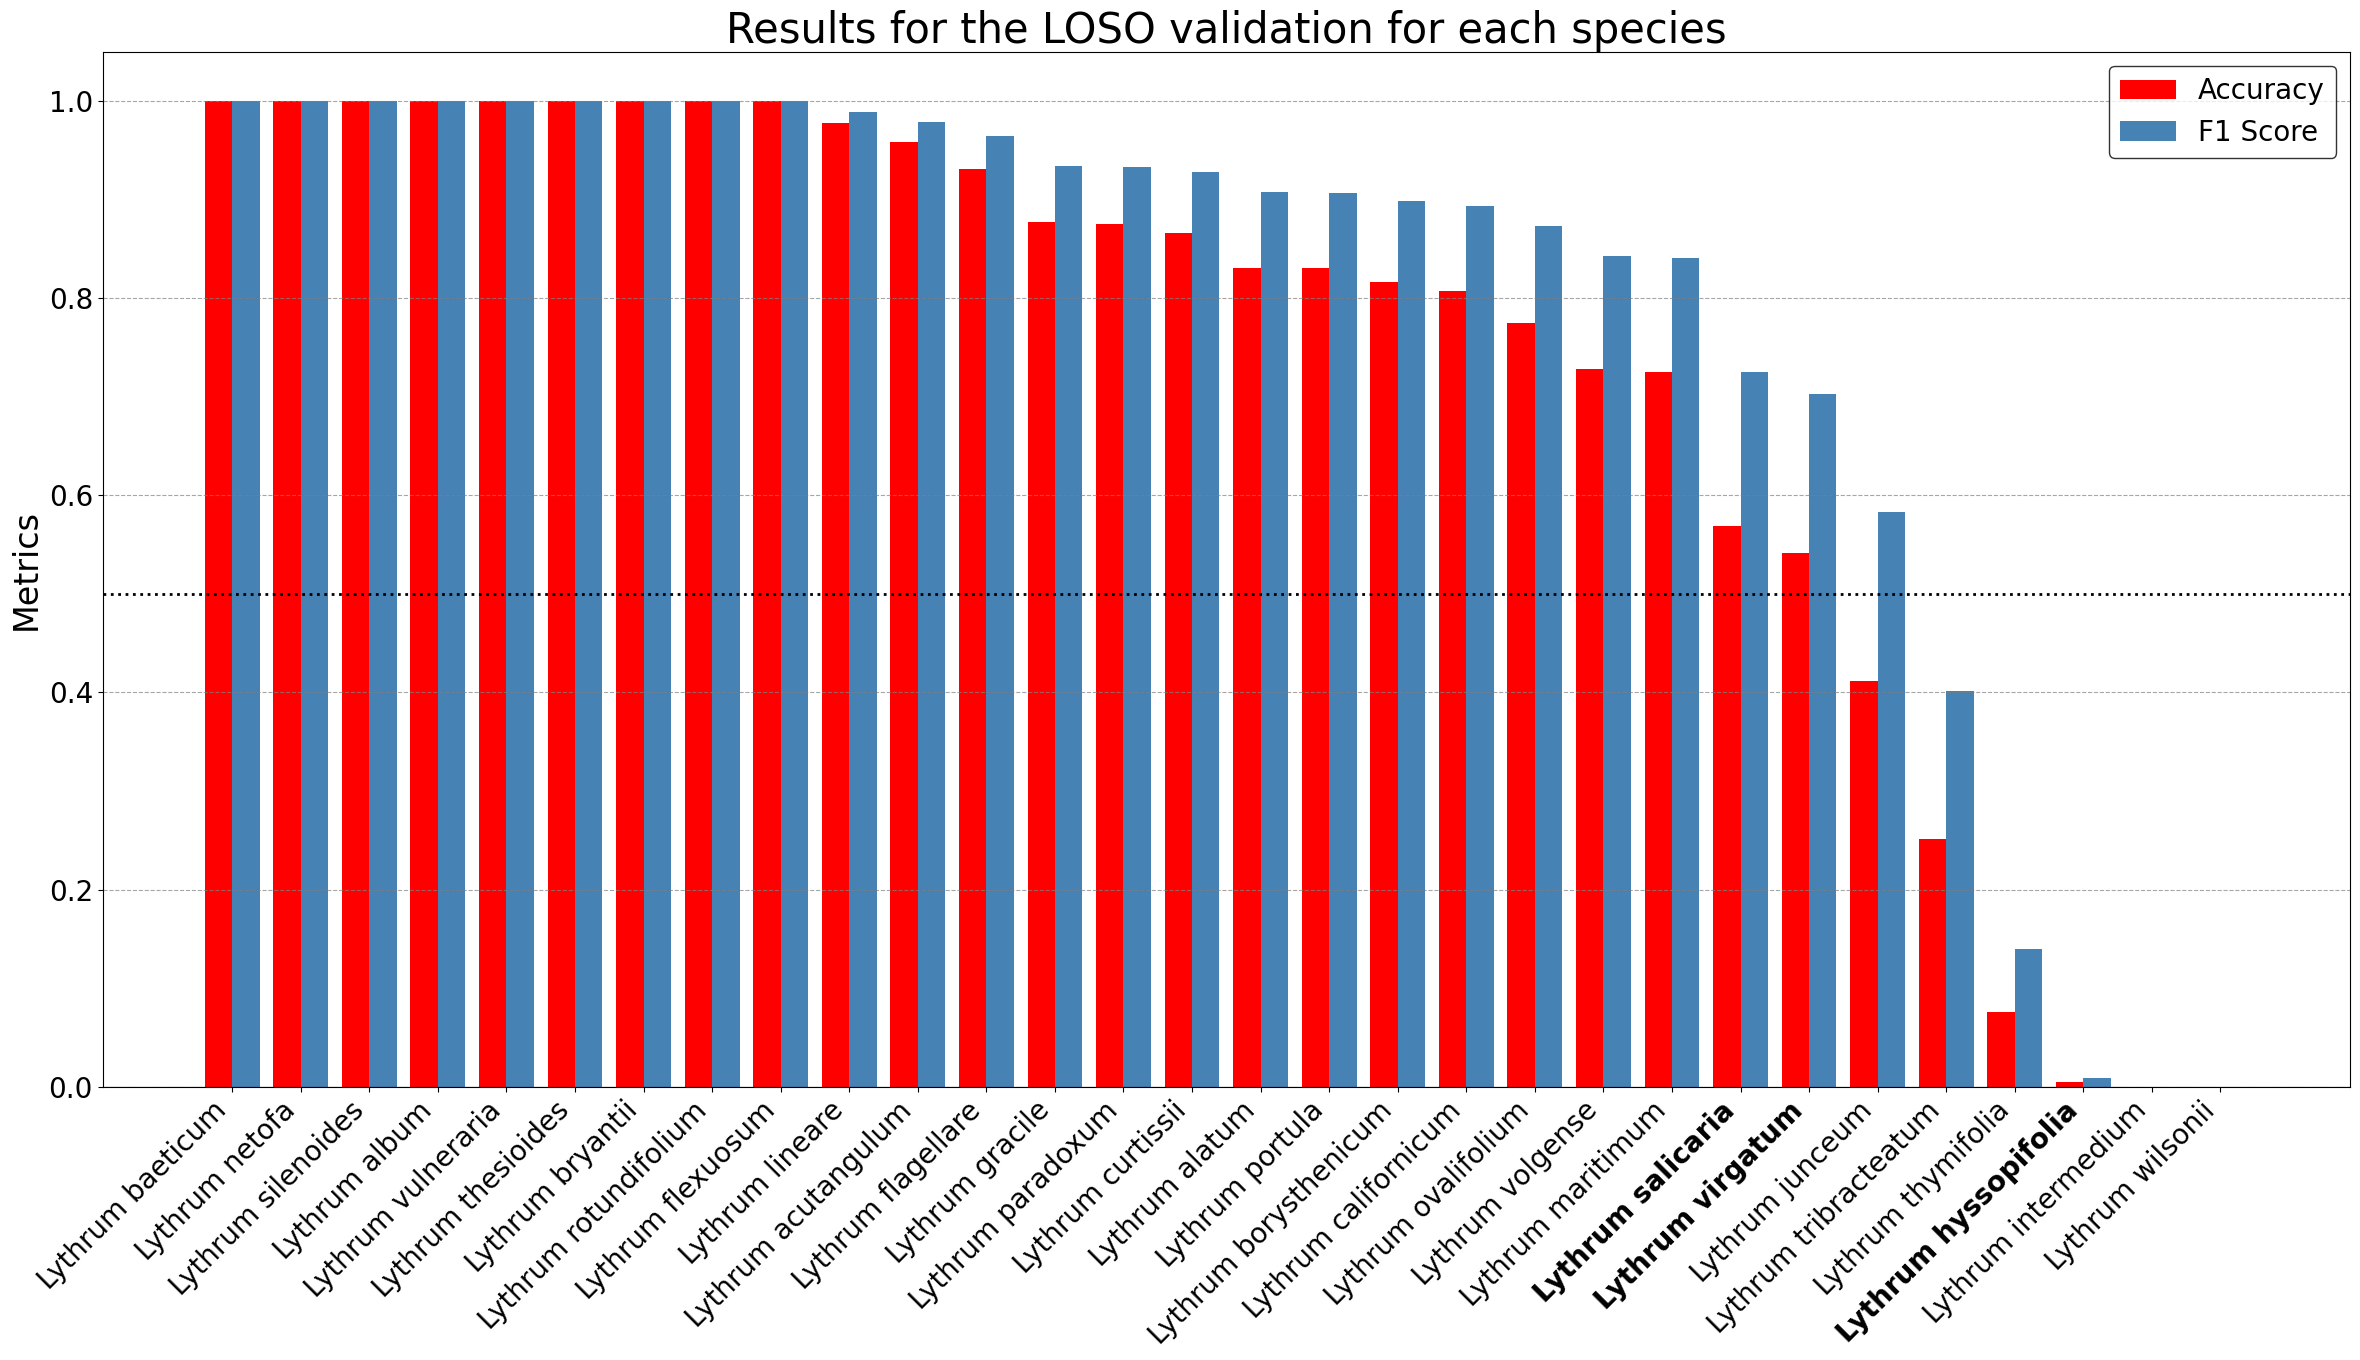

In [13]:
metrics_per_species_with_hyssopifolia_path_plot = "./support_files/accuracy_f1_per_species_with_hyssopifolia.pdf"
def analyze_and_plot_metrics(metrics_df, sort_by='n_samples', save_path=None):
    """
    Reads a dataframe containing the metrics for every species and returns a plot of the said metrics.
    
    Args:
        metrics_df (pd.DataFrame) : a dataframe containing the species and its metrics
        sort_by (str) : a string indicating on which metric to sort the plot
        save_path (str) : path to save the plot
    """
    
    # Sort by the magnitude of F1 difference for a more readable plo
    metrics_df = metrics_df.sort_values(sort_by, ascending=False)
    
    
    # 4. Plotting
    species = metrics_df['species']
        #Change species name
    species_updated = [s.split('_')[0].capitalize() + " " + s.split('_')[1] for s in species]


    recall = metrics_df['recall']
    f1 = metrics_df['f1_score']
    
    x = np.arange(len(species_updated))  # Y-axis label locations
    width = 0.4  # Height of the bars
    
    # --- FORCE WHITE BACKGROUND ---
    fig, ax = plt.subplots(figsize=(24, 14), facecolor='white')
    ax.set_facecolor('white')
    
    # Plot Bars
    ax.bar(x - width/2, recall, width, label='Accuracy', color='red')
    ax.bar(x + width/2, f1, width, label='F1 Score', color='steelblue')
    
    # --- FORCE BLACK TEXT & LINES (Fixes "Invisible Text" in Dark Mode) ---
    
    # 1. Axis Spines (Borders)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        
    # 2. Ticks and Labels
    ax.tick_params(axis='x', colors='black', labelcolor='black')
    ax.tick_params(axis='y', colors='black', labelcolor='black')
    
    # 3. Titles and Labels
    ax.set_ylabel('Metrics', color='black', fontsize=24)
    ax.set_title('Results for the LOSO validation for each species', color='black', fontsize=30)
    
    # 4. Y-Axis Species Names
    ax.set_xticks(x)
    ax.set_xticklabels(species_updated, color='black', rotation=45, ha='right')

    # Define the species you want to bold
    species_to_bold = ["Lythrum salicaria", "Lythrum virgatum", "Lythrum hyssopifolia"]

    # Iterate through the label objects and modify specific ones
    for label in ax.get_xticklabels():
        if label.get_text() in species_to_bold:
            label.set_fontweight('bold') 
            # Optional: You can also change fontsize or color here to highlight them further
            # label.set_fontsize(12)
    
    # 5. Legend
    legend = ax.legend(facecolor='white', edgecolor='black')
    plt.setp(legend.get_texts(), color='black')
    
    # 6. Grid and Zero Line
    ax.axhline(0, color='black', linewidth=0.8)
    ax.grid(axis='y', linestyle='--', alpha=0.7, color='gray')

    #add a baseline
    ax.axhline(0.5, color='black', linestyle=':', linewidth=2, label='Baseline (0.5)')

    
    plt.tight_layout()
    plt.savefig(save_path)
    
    return metrics_df

plt.rcParams.update({'font.size': 20}) # Sets default font size for everything

# Example Usage:
df_result = analyze_and_plot_metrics(metrics_df, sort_by='f1_score', save_path=metrics_per_species_with_hyssopifolia_path_plot)

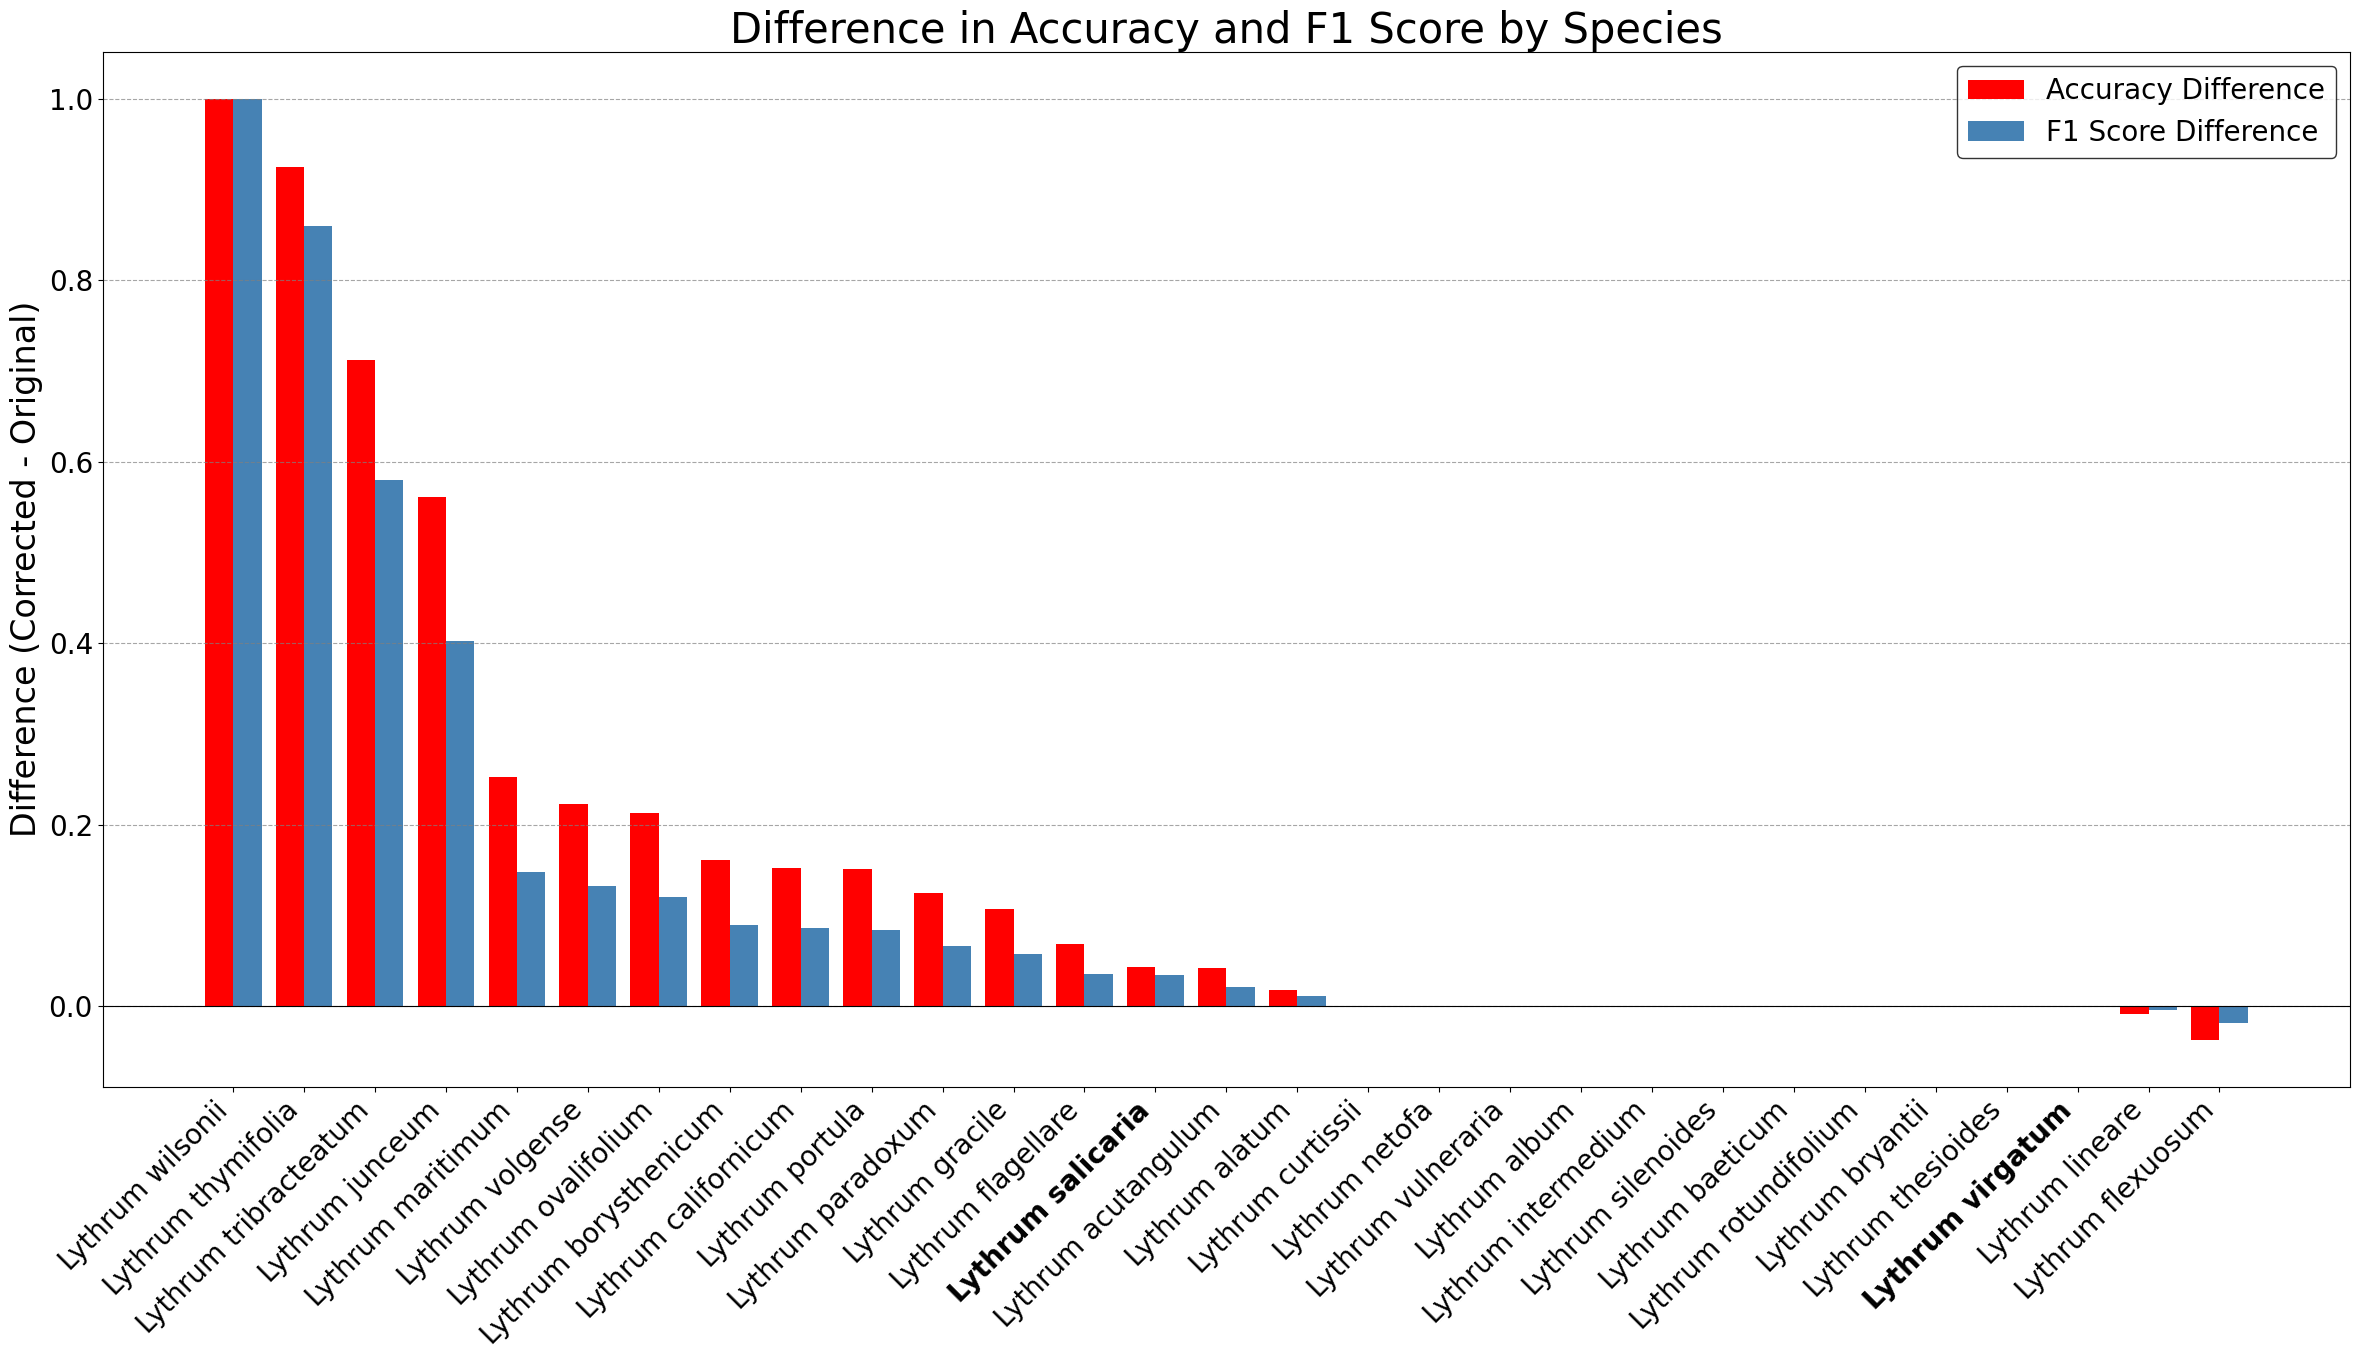

In [4]:
image_path_samples = './support_files/metrics_difference_sorted_by_samples.pdf'
image_path_f1 = './support_files/metrics_difference_sorted_by_f1_score.pdf'

def analyze_and_plot_differences(file1_path, file2_path, sort_by='f1'):
    """
    Reads two metrics CSV files, merges them by species, calculates the difference 
    in Recall and F1 Score, and generates a horizontal bar plot.
    
    Args:
        file1_path (str): Path to the original/reference CSV file.
        file2_path (str): Path to the corrected/comparison CSV file.
        output_image (str): Filename to save the resulting plot.
    """
    # 1. Load the datasets
    df1 = pd.read_csv(file1_path)
    df2 = pd.read_csv(file2_path)
    
    # 2. Merge on 'species' using an inner join (only common species are compared)
    # Suffixes distinguish between the original (df1) and corrected (df2) values
    merged_df = pd.merge(df1, df2, on='species', suffixes=('_original', '_corrected'))
    
    # 3. Calculate Differences (Corrected - Original)
    merged_df['recall_diff'] = merged_df['recall_corrected'] - merged_df['recall_original']
    merged_df['f1_diff'] = merged_df['f1_score_corrected'] - merged_df['f1_score_original']
    
    # Sort by the magnitude of F1 difference for a more readable plot
    if sort_by=='f1':
        merged_df = merged_df.sort_values('f1_diff', ascending=False)
    else:
        merged_df = merged_df.sort_values('n_samples_original', ascending=True)
    
    # 4. Plotting
    species = merged_df['species']
        #Change species name
    species_updated = [s.split('_')[0].capitalize() + " " + s.split('_')[1] for s in species]


    recall_diff = merged_df['recall_diff']
    f1_diff = merged_df['f1_diff']
    
    x = np.arange(len(species_updated))  # Y-axis label locations
    width = 0.4  # Height of the bars
    
    # --- FORCE WHITE BACKGROUND ---
    fig, ax = plt.subplots(figsize=(24, 14), facecolor='white')
    ax.set_facecolor('white')
    
    # Plot Bars
    ax.bar(x - width/2, recall_diff, width, label='Accuracy Difference', color='red')
    ax.bar(x + width/2, f1_diff, width, label='F1 Score Difference', color='steelblue')
    
    # --- FORCE BLACK TEXT & LINES (Fixes "Invisible Text" in Dark Mode) ---
    
    # 1. Axis Spines (Borders)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        
    # 2. Ticks and Labels
    ax.tick_params(axis='x', colors='black', labelcolor='black')
    ax.tick_params(axis='y', colors='black', labelcolor='black')
    
    # 3. Titles and Labels
    ax.set_ylabel('Difference (Corrected - Original)', color='black', fontsize=24)
    ax.set_title('Difference in Accuracy and F1 Score by Species', color='black', fontsize=30)
    
    # 4. Y-Axis Species Names
    ax.set_xticks(x)
    ax.set_xticklabels(species_updated, color='black', rotation=45, ha='right')

    # Define the species you want to bold
    species_to_bold = ["Lythrum salicaria", "Lythrum virgatum"]

    # Iterate through the label objects and modify specific ones
    for label in ax.get_xticklabels():
        if label.get_text() in species_to_bold:
            label.set_fontweight('bold') 
            # Optional: You can also change fontsize or color here to highlight them further
            # label.set_fontsize(12)
    
    # 5. Legend
    legend = ax.legend(facecolor='white', edgecolor='black')
    plt.setp(legend.get_texts(), color='black')
    
    # 6. Grid and Zero Line
    ax.axhline(0, color='black', linewidth=0.8)
    ax.grid(axis='y', linestyle='--', alpha=0.7, color='gray')
    
    plt.tight_layout()
    if sort_by=='f1':
        plt.savefig(image_path_f1)
    else:
        plt.savefig(image_path_samples)
    plt.show()
    
    return merged_df

plt.rcParams.update({'font.size': 20}) # Sets default font size for everything

# Example Usage:
df_result = analyze_and_plot_differences(
    "./support_files/metrics_per_species_with_hyssopifolia.csv", 
    "./support_files/Per-species_corrected_counts_and_metrics.csv",
    'f1'
    )